# Basic Functionality Tests

This notebook tests the `v2.0` model capabilities on dummy datasets to explore the versatility of its outputs.

Different tests are performed including simple $X \to y$ functions with noise, random noise target, and shaped target distributions.

Feel free to conduct any tests of your liking to get familiar with how the PFN output works and how to use the different `BucketOps`.

In [66]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Library imports
import torch
import matplotlib.pyplot as plt

In [67]:
# Import necessary utilities from my_small_PFN
from scripts.my_small_PFN import MyRegressorPFN, BucketOps

# Create a model with the trained weights
model = MyRegressorPFN("v2.0")

Model config' correctly loaded from C:\Users\PC\Desktop\My-Small-PFN\weights\v2.0\my_PFN_config.json
Model weights correctly loaded from C:\Users\PC\Desktop\My-Small-PFN\weights\v2.0\my_PFN_weights.pth


## $X\to y$ Functions With Noise

In [68]:
# Dimensions
train_size = 256
features = 14

# Create a random set of features
X_train = torch.randn([train_size, features])

# Create a random transformation from x to y
linear = torch.randn([7,])
transf = lambda x: torch.relu(x[:,-7:] * linear).sum(dim=-1, keepdim=True)

# Establish a noise function for the output
noise_std = 0.8
noise_func = lambda: torch.randn([train_size, 1]) * noise_std

# Apply and add noise
y_train = transf(X_train) + noise_func()

# Normalize
mean = y_train.mean(dim=0)
std = y_train.std(dim=0)
y_train = (y_train-mean)/std

# Make dummy test set with single row and calculate expected output
X_test = torch.randn([1, features])
expected_mean = ((transf(X_test) - mean) / std).item()
expected_std = (noise_std/std).item()

# Print necessary information
print(f"Dummy train and test splits generated with {train_size} rows and {features} features each.")
print(f"Single dummy test feature row generated, the expected output should be the following:")
print(f"Mean: {expected_mean:.2f} | STD: {expected_std:.2f}")

Dummy train and test splits generated with 256 rows and 14 features each.
Single dummy test feature row generated, the expected output should be the following:
Mean: 0.85 | STD: 0.53


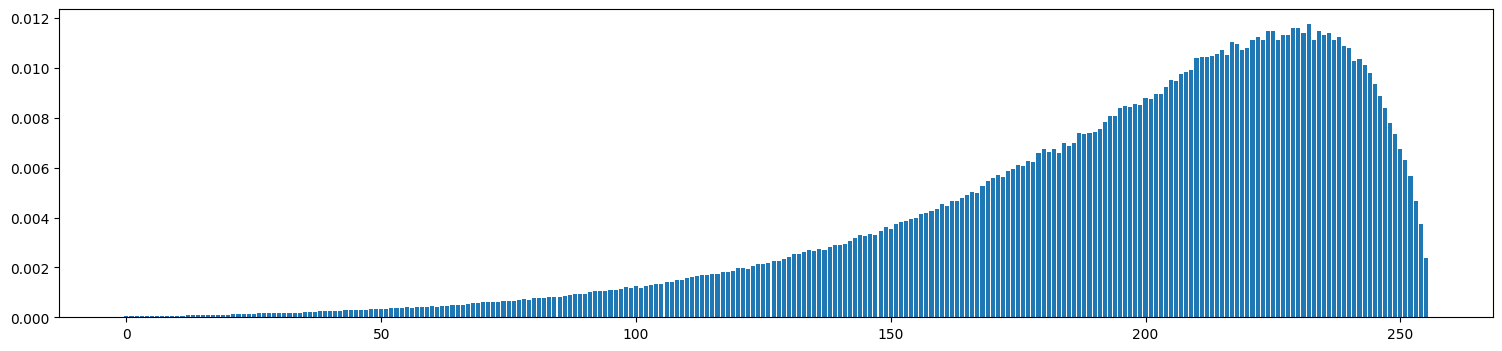

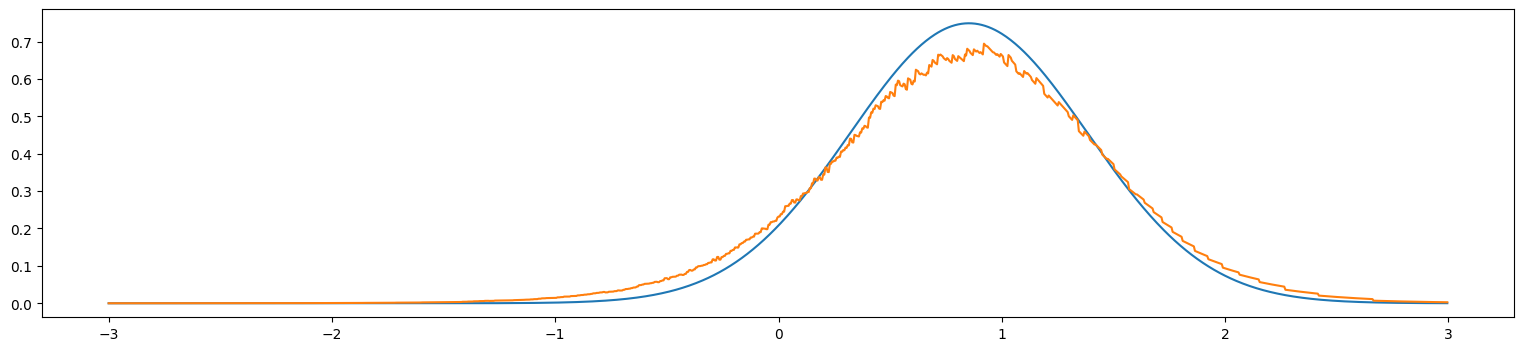

Mean, Variance, STD: (0.8337266445159912, 0.3948984742164612, 0.6284095048904419)


In [69]:
# Obtain probabilities on dummy test row
model.fit(X_train, y_train)
probs = model.predict(X_test, output='probs')

# Plot histogram
plt.figure(figsize=(18.5, 4))
plt.bar(range(model.config.n_buckets), probs)
plt.show()

# Plot distribution
_range = torch.arange(0,1200)/200-3
normal = lambda x,m,s: torch.e**(-(x-m)**2/(2*s**2))/(s*(2*torch.pi)**0.5)
plt.figure(figsize=(19, 4))
plt.plot(_range, normal(_range, expected_mean, expected_std))
plt.plot(_range,BucketOps.probs_to_distribution_plot(probs, _range))
plt.show()

# Print Values
print("Mean, Variance, STD:", BucketOps.probs_to_mean_var_std(probs))

## Random Noise Target

In [70]:
# Dimensions
train_size = 256
features = 24

# Create a random set of features
X_train = torch.randn([train_size, features])

# We can also consider a completely random target and see if the PFN notices that it is receiving noise
y_train = torch.randn([train_size,])

# Normalize
mean = y_train.mean(dim=0)
std = y_train.std(dim=0)
y_train = (y_train-mean)/std

# Make dummy test set with single row
X_test = torch.randn([1, features])

# Print necessary information
print(f"Dummy train and test splits generated with {train_size} rows and {features} features each.")
print("Single dummy test feature row generated. The input target is a random distribution.")

Dummy train and test splits generated with 256 rows and 24 features each.
Single dummy test feature row generated. The input target is a random distribution.


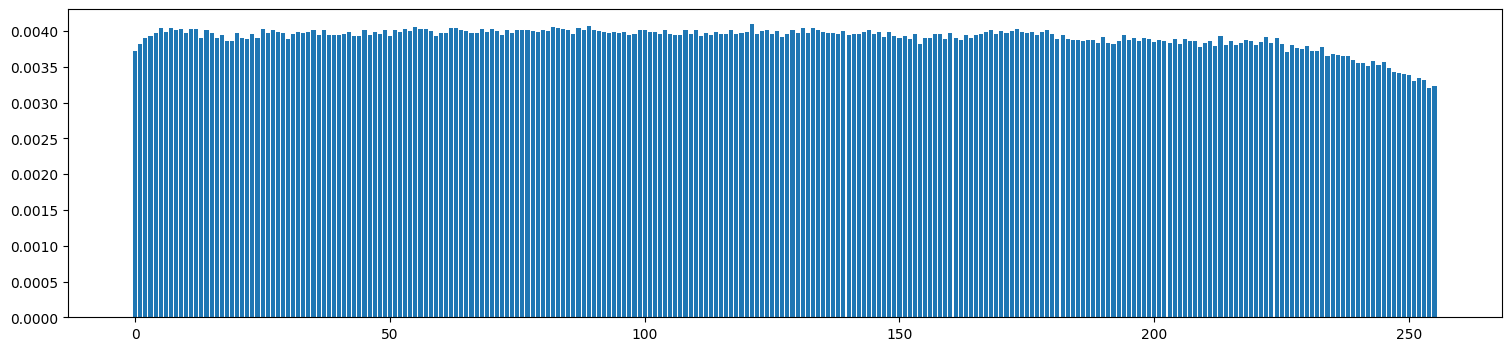

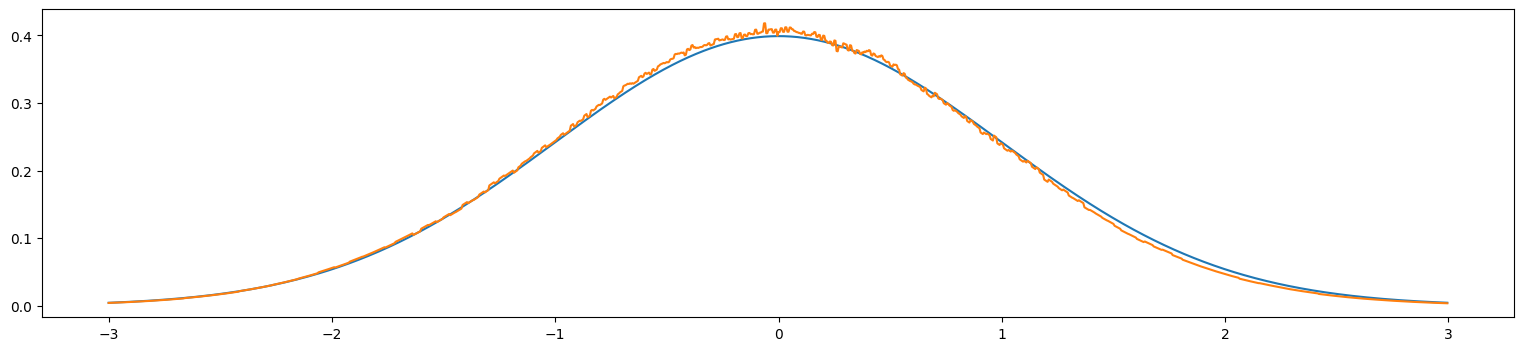

Mean, Variance, STD: (-0.026709405705332756, 0.9643989205360413, 0.982038140296936)


In [71]:
# Obtain probabilities on dummy test row
model.fit(X_train, y_train)
probs = model.predict(X_test, output='probs')

# Plot histogram
plt.figure(figsize=(18.5, 4))
plt.bar(range(model.config.n_buckets), probs)
plt.show()

# Plot distribution
_range = torch.arange(0,1200)/200-3
normal = lambda x: torch.e**(-x**2/2)/((2*torch.pi)**0.5)
plt.figure(figsize=(19, 4))
plt.plot(_range, normal(_range))
plt.plot(_range,BucketOps.probs_to_distribution_plot(probs, _range))
plt.show()

# Print Values
print("Mean, Variance, STD:", BucketOps.probs_to_mean_var_std(probs))

## Shaped Target Distribution

In [72]:
# Dimensions (no features)
train_size = 24
features = 0

# Create a random set of features
X_train = torch.randn([1, train_size, features])

# We can also consider shaped distributions for the target
# In this case two offset random distributions are concatenated
y_train = torch.cat([torch.randn([train_size//2,]) - 5, torch.randn([train_size//2,]) + 5])

# Normalize
mean = y_train.mean(dim=0)
std = y_train.std(dim=0)
y_train = (y_train-mean)/std

# Make dummy test set with single row
X_test = torch.randn([1, 1, features])

# Print necessary information
print(f"Dummy train and test splits generated with {train_size} rows and {features} features each.")
print("Single dummy test feature row generated. The input target is a shaped distribution.")

Dummy train and test splits generated with 24 rows and 0 features each.
Single dummy test feature row generated. The input target is a shaped distribution.


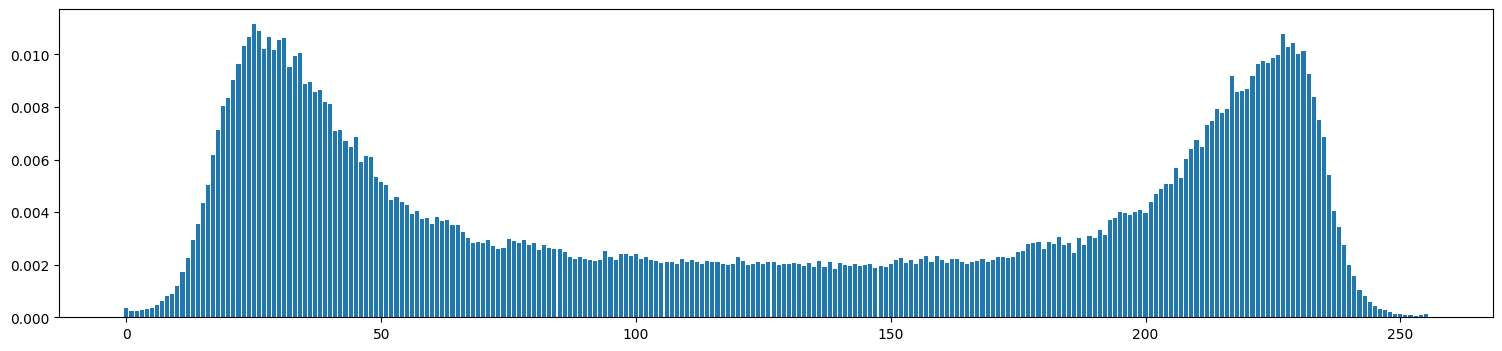

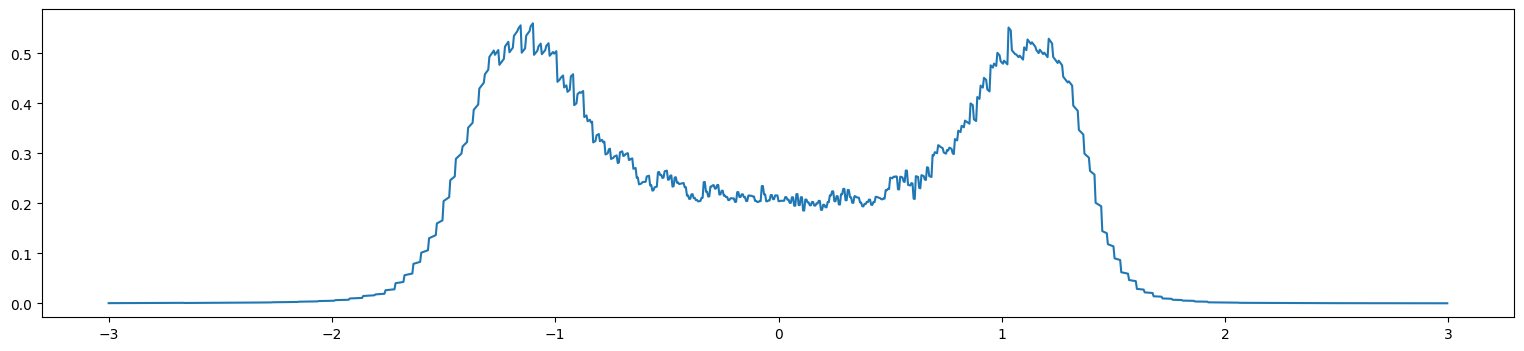

Mean, Variance, STD: (-0.052433643490076065, 0.9571672081947327, 0.9783492088317871)


In [73]:
# Obtain probabilities on dummy test row
model.fit(X_train, y_train)
probs = model.predict(X_test, output='probs')

# Plot histogram
plt.figure(figsize=(18.5, 4))
plt.bar(range(model.config.n_buckets), probs)
plt.show()

# Plot distribution
_range = torch.arange(0,1200)/200-3
plt.figure(figsize=(19, 4))
plt.plot(_range,BucketOps.probs_to_distribution_plot(probs, _range))
plt.show()

# Print Values
print("Mean, Variance, STD:", BucketOps.probs_to_mean_var_std(probs))